In [1]:
%pip install -q --no-warn-conflicts malariagen_data

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 36.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.1/216.1 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.7/71.7 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 119.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 120.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.9/775.9 kB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 116.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 68.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 83.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.3/211.3 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.

Note that authentication is required to access data through the package, please follow the instructions [here](https://malariagen.github.io/vector-data/vobs/vobs-data-access.html).

In [2]:
import malariagen_data

In [3]:
import pandas as pd
import numpy as np
import allel
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

In [4]:
import plotly.io as pio
pio.renderers.default = "notebook+colab"

In [ ]:
#import os
#os.environ["MGEN_SHOW_PROGRESS"] = "0"

In [5]:
ag3 = malariagen_data.Ag3()
ag3

<MalariaGEN Ag3 API client>
Storage URL                           : gs://vo_agam_release_master_us_central1/
Data releases available               : 3.0, 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 3.10, 3.11, 3.12, 3.13, 3.14
Results cache                         : None
Cohorts analysis                      : 20250815
AIM analysis                          : 20220528
Site filters analysis                 : dt_20200416
Software version                      : malariagen_data 15.5.0
Client location                       : South Carolina, United States (Google Cloud us-east1)
Data filtered to unrestricted use only: False
Data filtered to surveillance use only: False
Relevant data releases                : 3.0, 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 3.10, 3.11, 3.12, 3.13, 3.14
---
Please note that data are subject to terms of use,
for more information see https://www.malariagen.net/data
or contact support@malariagen.net. For API documentation see 
https://malariagen.github.io/malariagen-data-python/v15.5.0/Ag3.html

## Extract haplotypes from the region of interest

In [6]:
trra_haps = ag3.haplotypes(region="3L:36938555 - 36949962",
                           sample_sets="3.0")

In [ ]:
tpp_haps

<xarray.Dataset> Size: 80MB
Dimensions:           (variants: 14363, alleles: 2, samples: 2784, ploidy: 2)
Coordinates:
    variant_position  (variants) int32 57kB dask.array<chunksize=(14363,), meta=np.ndarray>
    variant_contig    (variants) uint8 14kB dask.array<chunksize=(14363,), meta=np.ndarray>
    sample_id         (samples) object 22kB dask.array<chunksize=(81,), meta=np.ndarray>
Dimensions without coordinates: variants, alleles, samples, ploidy
Data variables:
    variant_allele    (variants, alleles) |S1 29kB dask.array<chunksize=(14363, 1), meta=np.ndarray>
    call_genotype     (variants, samples, ploidy) int8 80MB dask.array<chunksize=(14363, 64, 2), meta=np.ndarray>
Attributes:
    contigs:   ('2R', '2L', '3R', '3L', 'X')
    analysis:  gamb_colu_arab

## Extract the variant positions

In [7]:
pos = allel.SortedIndex(sorted(trra_haps["variant_position"].values))
pos.shape

(3882,)

## Extract the haplotype itself

In [8]:
gt = trra_haps["call_genotype"].values

In [ ]:
gt.shape

(653, 2784, 2)

In [ ]:
gt

array([[[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]],

       [[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]],

       [[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]],

       ...,

       [[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]],

       [[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]],

       [[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]]], dtype=int8)

## Reshape the genotype to a two-dimensional data

In [9]:
ht = gt.reshape(gt.shape[0], -1)

In [ ]:
ht.shape

(14363, 5568)

## Convert to a Haplotype Array

In [10]:
haps = allel.HaplotypeArray(ht)

In [ ]:
haps.shape

(653, 5568)

In [ ]:
haps

<HaplotypeArray shape=(3882, 5568) dtype=int8>
0 0 0 0 0 ... 0 0 0 0 0
0 0 0 0 0 ... 0 0 0 0 0
0 0 0 0 0 ... 0 0 0 0 0
...
0 0 0 0 0 ... 0 0 0 0 0
0 0 0 0 0 ... 0 0 0 0 0
0 0 0 0 0 ... 0 0 0 0 0

In [ ]:
pos

0,1,2,3,4,...,648,649,650,651,652
np.int32(7163636),np.int32(7163641),np.int32(7163644),np.int32(7163645),np.int32(7163647),...,np.int32(7165291),np.int32(7165292),np.int32(7165300),np.int32(7165301),np.int32(7165309)


## Define the Transcript and the Cohort to work with

In [35]:
transcript = "AGAP012053-RB"

In [12]:
cohorts = "admin1_year"

## Call the SNPs in that transcript

In [36]:
variants = ag3.snp_allele_frequencies(transcript= transcript,
                                      cohorts= cohorts,
                                      sample_sets = '3.0',
                                      drop_invariant=False,
)
variants

Load SNP genotypes:   0%|          | 0/149 [00:00<?, ?it/s]

Compute allele frequencies:   0%|          | 0/54 [00:00<?, ?it/s]

Compute SNP effects:   0%|          | 0/27504 [00:00<?, ?it/s]

pass_gamb_colu_arab  \
contig position ref_allele alt_allele aa_change                        
3L     36938555 G          A          NaN                       True   
                           C          NaN                       True   
                           T          NaN                       True   
       36938556 T          A          NaN                       True   
                           C          NaN                       True   
...                                                              ...   
       36947721 C          T          NaN                       True   
                           G          NaN                       True   
       36947722 A          C          NaN                       True   
                           T          NaN                       True   
                           G          NaN                       True   

                                                 pass_gamb_colu  pass_arab  \
contig position ref_allele alt_allele aa_change                              
3L     36938555 G          A          NaN                  True       True   
                           C          NaN                  True       True   
                           T          NaN                  True       True   
       36938556 T          A          NaN                  True       True   
                           C          NaN                  True       True   
...                                                         ...        ...   
       36947721 C          T          NaN                  True       True   
                           G          NaN                  True       True   
       36947722 A          C          NaN                  True       True   
                           T          NaN                  True       True   
                           G          NaN                  True       True   

                                                 frq_AO-LUA_colu_2009  \
contig position ref_allele alt_allele aa_change                         
3L     36938555 G          A          NaN                    0.000000   
                           C          NaN                    0.000000   
                           T          NaN                    0.000000   
       36938556 T          A          NaN                    0.000000   
                           C          NaN                    0.000000   
...                                                               ...   
       36947721 C          T          NaN                    0.000000   
                           G          NaN                    0.000000   
       36947722 A          C          NaN                    0.000000   
                           T          NaN                    0.000000   
                           G          NaN                    0.938272   

                                                 frq_BF-07_gamb_2004  \
contig position ref_allele alt_allele aa_change                        
3L     36938555 G          A          NaN                   0.041667   
                           C          NaN                   0.000000   
                           T          NaN                   0.041667   
       36938556 T          A          NaN                   0.000000   
                           C          NaN                   0.000000   
...                                                              ...   
       36947721 C          T          NaN                   0.000000   
                           G          NaN                   0.000000   
       36947722 A          C          NaN                   0.000000   
                           T          NaN                   0.000000   
                           G          NaN                   0.846154   

                                                 frq_BF-09_colu_2012  \
contig position ref_allele alt_allele aa_change                        
3L     36938555 G          A          NaN                   0.0000

## Group such that only nsSNPs that occur at least once at a frequency of 0.05 in any cohort is extracted

In [37]:
missense_variants = variants.query("effect == 'NON_SYNONYMOUS_CODING' and max_af >= 0.05")
missense_variants

pass_gamb_colu_arab  \
contig position ref_allele alt_allele aa_change                        
3L     36939080 C          T          G544S                     True   
       36940669 G          A          T531I                     True   
       36940743 T          G          E506D                    False   
       36940760 T          C          S501G                    False   
       36940892 T          A          K483N                    False   
       36940899 A          T          F481Y                     True   
       36940903 T          G          T480P                     True   
       36940909 A          G          Y478H                     True   
       36940962 G          A          A460V                    False   
       36940967 G          C          D458E                     True   
       36940969 C          T          D458N                    False   
       36940994 C          G          M449I                    False   
       36941087 C          A          Q418H                     True   
       36941110 G          T          L411M                     True   
       36941113 T          C          I410V                     True   
       36941126 C          A          E405D                     True   
       36941129 C          G          K404N                     True   
       36941134 C          T          D403N                     True   
       36941136 T          G          E402A                     True   
       36941139 C          T          R401Q                     True   
       36941142 T          G          D400A                     True   
       36941149 A          T          C398S                     True   
       36941219 A          C          D374E                     True   
       36941230 C          T          A371T                     True   
       36941236 C          T          E369K                     True   
       36941238 G          T          A368E                    False   
       36941239 C          G          A368P                    False   
       36941296 A          C          Y349D                    False   
       36941319 C          T          G341D                     True   
       36941350 C          A          A331S                     True   
       36941406 C          T          R312H                    False   
       36941431 C          T          G304S                     True   
       36941490 G          A          A284V                     True   
                           C          A284G                     True   
       36941544 G          C          A266G                     True   
                           T          A266D                     True   
       36941550 C          G          S264T                     True   
       36941614 G          T          L243M                     True   
       36941932 G          C          P137A                    False   
       36941971 G          T          L124I                     True   
       36942056 G          C          A119G                     True   
       36942066 A          T          S116T                    False   
       36942129 C          T          D95N                      True   
       36942144 G          T          R90S                      True   
       36942146 G          A          A89V                      True   
       36942153 A          C          F87V                      True   
       36942161 C          A          S84I                      True   
       36942167 G          C          T82S                      True   
       36942177 C          T          D79N                      True   
       36942182 G          T          T77K                      True   
       36942221 A          G          L64S                     False   
       36942234 C          G          E60Q                      True   
       36942318 G          A          R32C                     False   
       36942320 A          C          M31R                     False   

                

## Extract the indexes

In [38]:
trrb_index = missense_variants[[]]
trrb_index


Empty DataFrame
Columns: []
Index: [(3L, 36939080, C, T, G544S), (3L, 36940669, G, A, T531I), (3L, 36940743, T, G, E506D), (3L, 36940760, T, C, S501G), (3L, 36940892, T, A, K483N), (3L, 36940899, A, T, F481Y), (3L, 36940903, T, G, T480P), (3L, 36940909, A, G, Y478H), (3L, 36940962, G, A, A460V), (3L, 36940967, G, C, D458E), (3L, 36940969, C, T, D458N), (3L, 36940994, C, G, M449I), (3L, 36941087, C, A, Q418H), (3L, 36941110, G, T, L411M), (3L, 36941113, T, C, I410V), (3L, 36941126, C, A, E405D), (3L, 36941129, C, G, K404N), (3L, 36941134, C, T, D403N), (3L, 36941136, T, G, E402A), (3L, 36941139, C, T, R401Q), (3L, 36941142, T, G, D400A), (3L, 36941149, A, T, C398S), (3L, 36941219, A, C, D374E), (3L, 36941230, C, T, A371T), (3L, 36941236, C, T, E369K), (3L, 36941238, G, T, A368E), (3L, 36941239, C, G, A368P), (3L, 36941296, A, C, Y349D), (3L, 36941319, C, T, G341D), (3L, 36941350, C, A, A331S), (3L, 36941406, C, T, R312H), (3L, 36941431, C, T, G304S), (3L, 36941490, G, A, A284V), (3L, 36941490, G, C, A284G), (3L, 36941544, G, C, A266G), (3L, 36941544, G, T, A266D), (3L, 36941550, C, G, S264T), (3L, 36941614, G, T, L243M), (3L, 36941932, G, C, P137A), (3L, 36941971, G, T, L124I), (3L, 36942056, G, C, A119G), (3L, 36942066, A, T, S116T), (3L, 36942129, C, T, D95N), (3L, 36942144, G, T, R90S), (3L, 36942146, G, A, A89V), (3L, 36942153, A, C, F87V), (3L, 36942161, C, A, S84I), (3L, 36942167, G, C, T82S), (3L, 36942177, C, T, D79N), (3L, 36942182, G, T, T77K), (3L, 36942221, A, G, L64S), (3L, 36942234, C, G, E60Q), (3L, 36942318, G, A, R32C), (3L, 36942320, A, C, M31R)]

## Conver the object to a dataframe

In [39]:
trrb_df = pd.DataFrame(list(trrb_index.index), columns=[
    "contig", "position", "ref_allele", "alt_allele", "aa_change"
])
trrb_df

,contig,position,ref_allele,alt_allele,aa_change
0,3L,36939080,C,T,G544S
1,3L,36940669,G,A,T531I
2,3L,36940743,T,G,E506D
3,3L,36940760,T,C,S501G
4,3L,36940892,T,A,K483N
5,3L,36940899,A,T,F481Y
6,3L,36940903,T,G,T480P
7,3L,36940909,A,G,Y478H
8,3L,36940962,G,A,A460V
9,3L,36940967,G,C,D458E


## Sort the positions of the selected variants

In [40]:
pos_selected = allel.SortedIndex(sorted(trrb_df['position']))

In [41]:
pos_selected

0,1,2,3,4,...,49,50,51,52,53
np.int64(36939080),np.int64(36940669),np.int64(36940743),np.int64(36940760),np.int64(36940892),...,np.int64(36942182),np.int64(36942221),np.int64(36942234),np.int64(36942318),np.int64(36942320)


## Use that file to locate the keys of the positions in the main position file. Set the strict parameter to ensure that only the present positions are called, else it will create an error.

In [42]:
loc_selected = pos.locate_keys(pos_selected, strict= False)
loc_selected

array([False, False, False, ..., False, False, False])

## Use said file to select the haplotypes corresponding to the selected positions

In [43]:
haps_selected = haps[loc_selected]
haps_selected

<HaplotypeArray shape=(20, 5568) dtype=int8>
0 0 0 0 0 ... 0 0 0 0 0
0 0 0 1 1 ... 0 1 1 0 0
0 0 0 0 0 ... 0 0 0 0 0
...
0 0 0 0 0 ... 0 0 0 0 0
0 0 0 0 0 ... 0 0 0 0 0
0 0 0 0 0 ... 0 0 0 0 0

## Define a function that checks the position in pos_selected that are not found in pos so they can be easily removed

In [44]:
def get_missing_values(idx1, idx2):
    missing_values = []
    for i in idx1:
        if i not in idx2:
            missing_values.append(i)
    return missing_values

In [45]:
values_to_remove = get_missing_values(pos_selected, pos)

## this creates a dataframe that holds the mutations whose haplotypes are present.

In [46]:
trrb_df2 = trrb_df[~trrb_df["position"].isin(values_to_remove)]
trrb_df2.shape

(20, 5)

## this creates a dataframe to show which mutations were not present and were subsequently removed

In [48]:
trrb_mut = trrb_df[trrb_df["position"].isin(values_to_remove)]
trrb_mut.shape

(34, 5)

In [49]:
ac = haps_selected.count_alleles()
ac.displayall()

,0,1
0,5567,1
1,4094,1474
2,5567,1
3,5567,1
4,4998,570
5,5567,1
6,5564,4
7,5540,28
8,5511,57
9,5566,2


## Define the function to compute the Lenwontin D'

In [50]:
def lewontin_d_prime(h, i, j, a=1, b=1):
    """
    h = haplotype matrix (SNPs × haplotypes)
    i = index of SNP1
    j = index of SNP2
    a = derived allele at SNP1
    b = derived allele at SNP2
    """
    n_a = n_b = 0
    n_ab = 0
    n = 0

    for k in range(h.shape[1]):
        allele_i = h[i, k]
        allele_j = h[j, k]
        if allele_i < 0 or allele_j < 0:
            continue

        if allele_i == a:
            n_a += 1
        if allele_j == b:
            n_b += 1
        if allele_i == a and allele_j == b:
            n_ab += 1
        n += 1

    if n == 0 or n_a == 0 or n_b == 0 or n == n_a or n == n_b:
        return np.nan

    D = (n * n_ab) - (n_a * n_b)

    if D >= 0:
        Dmax = min(n_a * (n - n_b), (n - n_a) * n_b)
    else:
        Dmax = min(n_a * n_b, (n - n_a) * (n - n_b))

    return D / Dmax

## Create the pairwise matrix

In [51]:
n = haps_selected.shape[0]
ld_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(i + 1, n):
        dprime = lewontin_d_prime(haps_selected, i, j, 1, 1)
        ld_matrix[i, j] = dprime
        ld_matrix[j, i] = dprime

## create a new column that combines all the information in your dataframe

In [52]:
trrb_df2["label"] = (
    trrb_df2["position"].astype(str)
    + ": "
    + trrb_df2["ref_allele"].astype(str)
    + ">"
    + trrb_df2["alt_allele"].astype(str)
    + " "
    + trrb_df2["aa_change"]
)
trrb_df2

/tmp/ipython-input-3753896264.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,contig,position,ref_allele,alt_allele,aa_change,label
1,3L,36940669,G,A,T531I,36940669: G>A T531I
5,3L,36940899,A,T,F481Y,36940899: A>T F481Y
6,3L,36940903,T,G,T480P,36940903: T>G T480P
7,3L,36940909,A,G,Y478H,36940909: A>G Y478H
14,3L,36941113,T,C,I410V,36941113: T>C I410V
15,3L,36941126,C,A,E405D,36941126: C>A E405D
17,3L,36941134,C,T,D403N,36941134: C>T D403N
19,3L,36941139,C,T,R401Q,36941139: C>T R401Q
21,3L,36941149,A,T,C398S,36941149: A>T C398S
24,3L,36941236,C,T,E369K,36941236: C>T E369K


## create an array of your labels to be used

In [53]:
labels = trrb_df2["label"].to_numpy()

In [54]:
ld_df = pd.DataFrame(ld_matrix, index=labels, columns=labels)

In [55]:
ld_df.to_excel("trrbld_matrix.xlsx")

## Plotting the heatmap

##define a function that plots your heatmap with gridspace

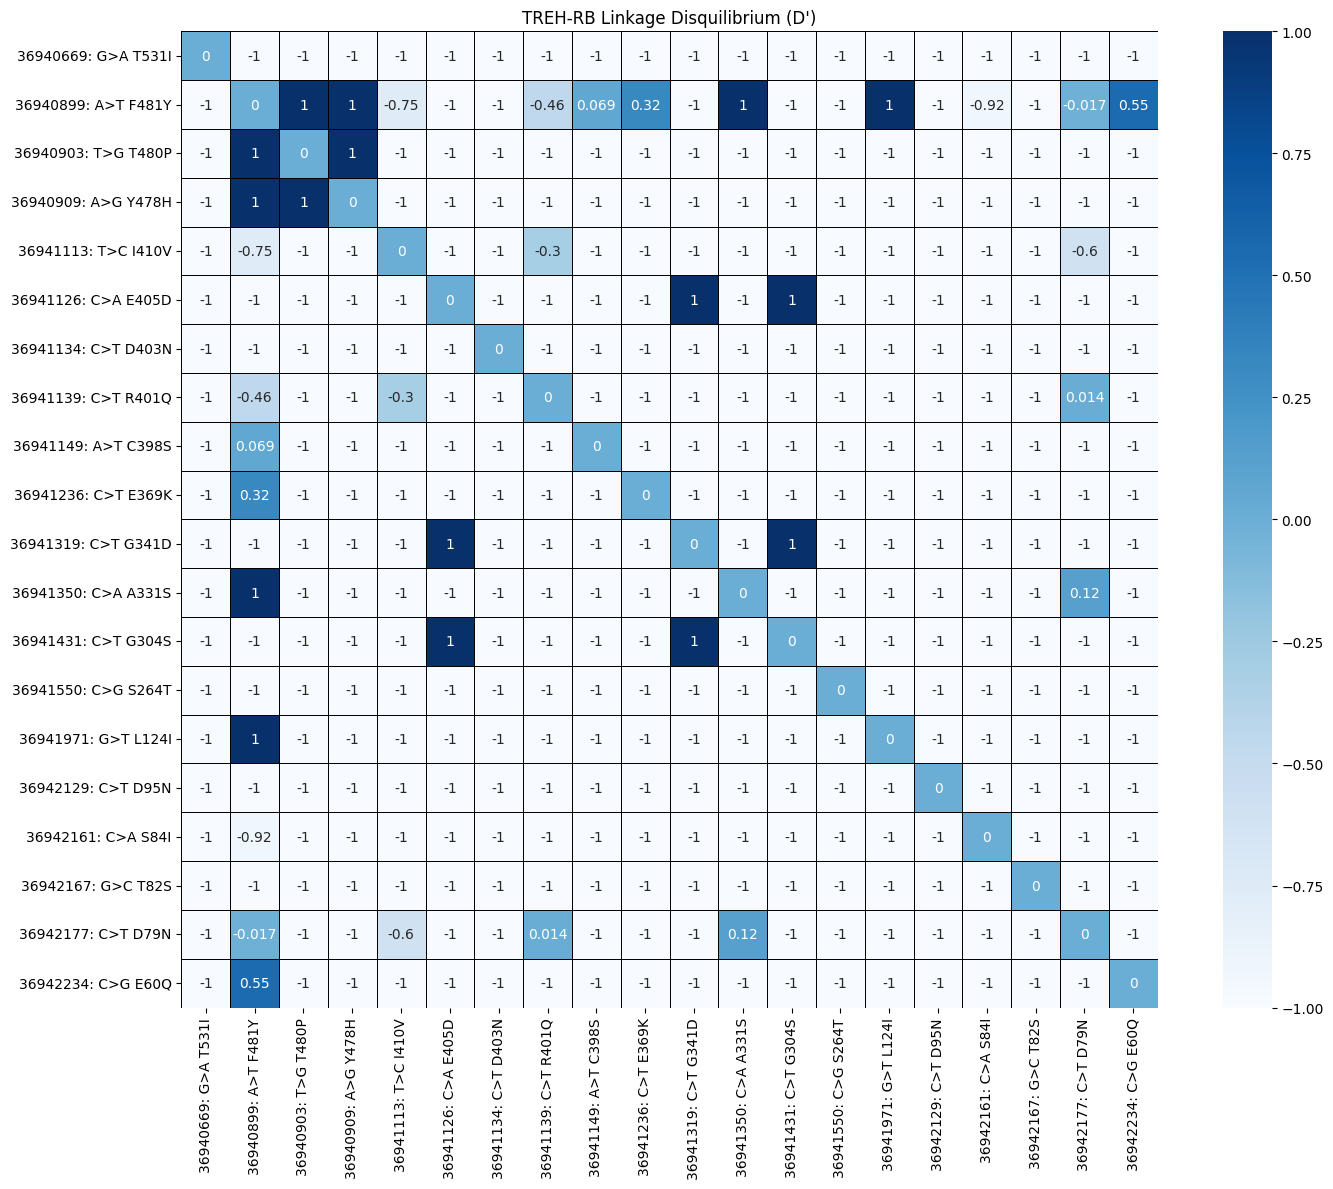

In [56]:
def plot_ld_with_gridspec(ld_df, title="TREH-RB Linkage Disquilibrium (D')"):
    n = ld_df.shape[0]

    fig = plt.figure(figsize=(15, 12))
    gs = gridspec.GridSpec(1, 1, figure=fig)

    ax = fig.add_subplot(gs[0, 0])


    sns.heatmap(
        ld_df,
        cmap="Blues",
        annot=True,
        vmin=-1, vmax=1, center=0,
        square=True,
        linewidths=0.5,
        linecolor="black",
        xticklabels=True,
        yticklabels=True,
        ax=ax
    )

    ax.set_title(title)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.tick_params(axis='both', which='major')

    plt.tight_layout()
    plt.show()


plot_ld_with_gridspec(ld_df)
